In [ ]:
from sklearn.datasets import fetch_openml
df = fetch_openml(name = 'adult', version = 2, as_frame = True)
x, y = df.data, df.target

In [ ]:
x.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB


In [ ]:
y.head()

,class
0,<=50K
1,<=50K
2,>50K
3,>50K
4,<=50K


In [ ]:
miss = x.isnull().sum()
miss = miss[miss>0].sort_values(ascending = False)
miss

,0
occupation,2809
workclass,2799
native-country,857


In [ ]:
x_copy = x.select_dtypes(include = ['object','category'])
for cols in x_copy:
  print(x[cols].value_counts())
  print('\n')

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64


occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical   

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
si = SimpleImputer(strategy = 'most_frequent')
cat = x.select_dtypes(include = ['object','category']).columns
x[cat] = si.fit_transform(x[cat])

/tmp/ipython-input-778446460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[cat] = si.fit_transform(x[cat])


In [ ]:
oe = OrdinalEncoder()
x[cat] = oe.fit_transform(x[cat])

/tmp/ipython-input-2457582468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[cat] = oe.fit_transform(x[cat])


In [ ]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,3.0,226802,1.0,7,4.0,6.0,3.0,2.0,1.0,0,0,40,38.0
1,38,3.0,89814,11.0,9,2.0,4.0,0.0,4.0,1.0,0,0,50,38.0
2,28,1.0,336951,7.0,12,2.0,10.0,0.0,4.0,1.0,0,0,40,38.0
3,44,3.0,160323,15.0,10,2.0,6.0,0.0,2.0,1.0,7688,0,40,38.0
4,18,3.0,103497,15.0,10,4.0,9.0,3.0,4.0,0.0,0,0,30,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3.0,257302,7.0,12,2.0,12.0,5.0,4.0,0.0,0,0,38,38.0
48838,40,3.0,154374,11.0,9,2.0,6.0,0.0,4.0,1.0,0,0,40,38.0
48839,58,3.0,151910,11.0,9,6.0,0.0,4.0,4.0,0.0,0,0,40,38.0
48840,22,3.0,201490,11.0,9,4.0,0.0,3.0,4.0,1.0,0,0,20,38.0


In [ ]:
x_ca = x.copy()
x_a = x_ca[cat].astype(int)
x_ca.astype(int)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,3,226802,1,7,4,6,3,2,1,0,0,40,38
1,38,3,89814,11,9,2,4,0,4,1,0,0,50,38
2,28,1,336951,7,12,2,10,0,4,1,0,0,40,38
3,44,3,160323,15,10,2,6,0,2,1,7688,0,40,38
4,18,3,103497,15,10,4,9,3,4,0,0,0,30,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3,257302,7,12,2,12,5,4,0,0,0,38,38
48838,40,3,154374,11,9,2,6,0,4,1,0,0,40,38
48839,58,3,151910,11,9,6,0,4,4,0,0,0,40,38
48840,22,3,201490,11,9,4,0,3,4,1,0,0,20,38


In [ ]:
x_ca

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,3.0,226802,1.0,7,4.0,6.0,3.0,2.0,1.0,0,0,40,38.0
1,38,3.0,89814,11.0,9,2.0,4.0,0.0,4.0,1.0,0,0,50,38.0
2,28,1.0,336951,7.0,12,2.0,10.0,0.0,4.0,1.0,0,0,40,38.0
3,44,3.0,160323,15.0,10,2.0,6.0,0.0,2.0,1.0,7688,0,40,38.0
4,18,3.0,103497,15.0,10,4.0,9.0,3.0,4.0,0.0,0,0,30,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,3.0,257302,7.0,12,2.0,12.0,5.0,4.0,0.0,0,0,38,38.0
48838,40,3.0,154374,11.0,9,2.0,6.0,0.0,4.0,1.0,0,0,40,38.0
48839,58,3.0,151910,11.0,9,6.0,0.0,4.0,4.0,0.0,0,0,40,38.0
48840,22,3.0,201490,11.0,9,4.0,0.0,3.0,4.0,1.0,0,0,20,38.0


In [ ]:
y.value_counts()

,count
class,
<=50K,37155
>50K,11687


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
y

array([0, 0, 1, ..., 0, 0, 1])

In [ ]:
x_ca = x_ca.drop('race', axis = 1)

KeyError: "['race'] not found in axis"

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
x_train, x_test, y_train, y_test = train_test_split(x_ca, y, test_size = 0.35, random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 2000, solver = 'lbfgs')
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [ ]:
predlr = lr.predict(x_test)
print(classification_report(y_test,predlr))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89     13068
           1       0.69      0.39      0.50      4027

    accuracy                           0.81     17095
   macro avg       0.76      0.67      0.69     17095
weighted avg       0.80      0.81      0.79     17095



In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight= 'balanced', max_depth= 20)
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=20)

In [ ]:
preddt = dt.predict(x_test)
print(classification_report(y_test,preddt))

              precision    recall  f1-score   support

           0       0.92      0.83      0.87     13068
           1       0.58      0.76      0.66      4027

    accuracy                           0.81     17095
   macro avg       0.75      0.80      0.77     17095
weighted avg       0.84      0.81      0.82     17095



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight= 'balanced', max_depth= 20)
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20)

In [ ]:
predrf = rf.predict(x_test)
print(classification_report(y_test,predrf))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90     13068
           1       0.66      0.77      0.71      4027

    accuracy                           0.85     17095
   macro avg       0.79      0.82      0.81     17095
weighted avg       0.86      0.85      0.86     17095



AUC for Decision Tree: 0.8197
AUC for Random Forest: 0.9168


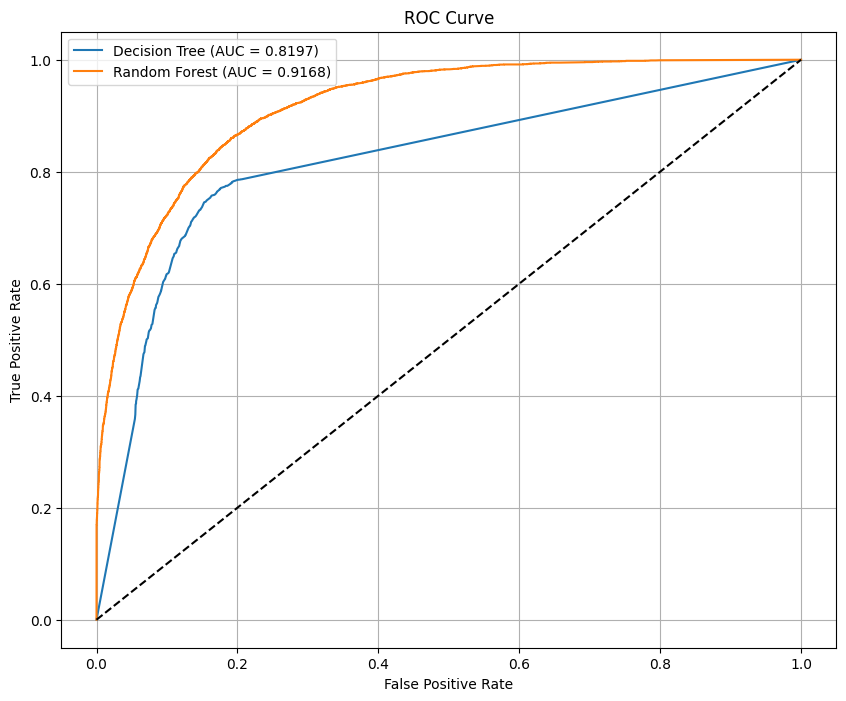

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate probabilities for the positive class
y_pred_dt_proba = dt.predict_proba(x_test)[:, 1]
y_pred_rf_proba = rf.predict_proba(x_test)[:, 1]

# Calculate ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)

# Calculate AUC
auc_dt = roc_auc_score(y_test, y_pred_dt_proba)
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)

print(f'AUC for Decision Tree: {auc_dt:.4f}')
print(f'AUC for Random Forest: {auc_rf:.4f}')

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--') # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Get feature importances from Decision Tree
dt_feature_importances = pd.Series(dt.feature_importances_, index=x_train.columns).sort_values(ascending=False)

# Get feature importances from Random Forest
rf_feature_importances = pd.Series(rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)

print("Decision Tree Feature Importances:")
display(dt_feature_importances)

print("\nRandom Forest Feature Importances:")
display(rf_feature_importances)

Decision Tree Feature Importances:


,0
relationship,0.346541
fnlwgt,0.125553
education-num,0.116832
capital-gain,0.108031
age,0.103857
hours-per-week,0.062971
occupation,0.044593
capital-loss,0.033948
workclass,0.023119
native-country,0.015069



Random Forest Feature Importances:


,0
relationship,0.164584
marital-status,0.138386
age,0.137635
education-num,0.101709
fnlwgt,0.097928
capital-gain,0.091791
hours-per-week,0.082895
occupation,0.052613
education,0.043747
workclass,0.029099
